In [1]:
%matplotlib inline
import torch
from torch.distributions import multinomial
from d2l import torch as d2l

In [2]:
fair_probs = torch.ones([6]) / 6
multinomial.Multinomial(1, fair_probs).sample()

tensor([1., 0., 0., 0., 0., 0.])

In [3]:
multinomial.Multinomial(10,fair_probs).sample()
#.sample() 执行一次实验，返回每个选项出现的次数。

tensor([1., 2., 2., 3., 2., 0.])

In [4]:
counts = multinomial.Multinomial(1000, fair_probs).sample()
counts / 1000


tensor([0.1840, 0.1670, 0.1630, 0.1550, 0.1670, 0.1640])

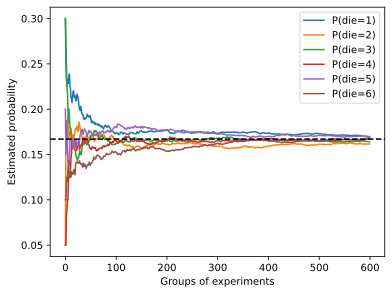

In [11]:
counts = multinomial.Multinomial(20, fair_probs).sample((600,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdim=True)
#print(estimates)

d2l.set_figsize((6, 4.5))
for i in range(6):
    d2l.plt.plot(estimates[:, i].numpy(),
                 label="P(die=" + str(i + 1) + ")")
d2l.plt.axhline(y=0.167, color='black', linestyle='dashed') ## 画水平虚线
d2l.plt.gca().set_xlabel('Groups of experiments')
d2l.plt.gca().set_ylabel('Estimated probability')
d2l.plt.legend()




### 练习

In [24]:
fair_probs = torch.tensor([1/3, 1/6, 1/6, 1/6, 1/12, 1/12])

x = multinomial.Multinomial(1000, fair_probs).sample()  
p = x / x.sum()
print(x)
print(p)
torch.allclose(p, fair_probs, atol=0.05) # 允许5%的误差
#atol = absolute tolerance（绝对误差容忍度）。

tensor([346., 167., 148., 171.,  75.,  93.])
tensor([0.3460, 0.1670, 0.1480, 0.1710, 0.0750, 0.0930])


True